# Manual EDA on E-commerce Dataset

In [1]:
import sys
print(sys.version)

3.10.20 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:13:20) [MSC v.1942 64 bit (AMD64)]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Load the dataset

In [3]:
df_estore = pd.read_csv("C:/Users/GAURAV SARKAR/Ecommerce_manual_eda/Data/ecommerce_dataset_updated.csv")
df_estore

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-24
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-24
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-24
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-24
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-24
...,...,...,...,...,...,...,...,...
3655,67abda0a,28714133-6,Beauty,486.79,0,486.79,UPI,14-05-24
3656,34ebc1a0,08838c2c-9,Toys,212.87,15,180.94,Cash on Delivery,19-11-24
3657,1defd3b1,c39a4f16-6,Home & Kitchen,389.76,0,389.76,Net Banking,07-08-24
3658,0611293d,b4f67f96-9,Electronics,447.66,30,313.36,UPI,21-05-24


### Viewing first few rows

In [4]:
df_estore.head(6)

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
0,337c166f,f414122f-e,Sports,36.53,15,31.05,Net Banking,12-11-24
1,d38a19bf,fde50f9c-5,Clothing,232.79,20,186.23,Net Banking,09-02-24
2,d7f5f0b0,0d96fc90-3,Sports,317.02,25,237.76,Credit Card,01-09-24
3,395d4994,964fc44b-d,Toys,173.19,25,129.89,UPI,01-04-24
4,a83c145c,d70e2fc6-e,Beauty,244.80,20,195.84,Net Banking,27-09-24
5,3fdcdae8,0816ee12-5,Books,241.86,50,120.93,UPI,08-08-24


In [5]:
df_estore.tail()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
3655,67abda0a,28714133-6,Beauty,486.79,0,486.79,UPI,14-05-24
3656,34ebc1a0,08838c2c-9,Toys,212.87,15,180.94,Cash on Delivery,19-11-24
3657,1defd3b1,c39a4f16-6,Home & Kitchen,389.76,0,389.76,Net Banking,07-08-24
3658,0611293d,b4f67f96-9,Electronics,447.66,30,313.36,UPI,21-05-24
3659,e73ad07c,a5d07442-d,Home & Kitchen,235.77,30,165.04,UPI,14-04-24


In [6]:
df_estore.sample()

,User_ID,Product_ID,Category,Price (Rs.),Discount (%),Final_Price(Rs.),Payment_Method,Purchase_Date
2866,6c6bc323,ffa4a462-b,Beauty,418.98,15,356.13,Credit Card,16-02-24


In [7]:
df_estore.shape

(3660, 8)

In [8]:
df_estore.columns

Index(['User_ID', 'Product_ID', 'Category', 'Price (Rs.)', 'Discount (%)',
       'Final_Price(Rs.)', 'Payment_Method', 'Purchase_Date'],
      dtype='object')

In [9]:
df_estore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           3660 non-null   object 
 1   Product_ID        3660 non-null   object 
 2   Category          3660 non-null   object 
 3   Price (Rs.)       3660 non-null   float64
 4   Discount (%)      3660 non-null   int64  
 5   Final_Price(Rs.)  3660 non-null   float64
 6   Payment_Method    3660 non-null   object 
 7   Purchase_Date     3660 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 228.9+ KB


## Summary Statistics

In [10]:
df_estore.describe()

,Price (Rs.),Discount (%),Final_Price(Rs.)
count,3660.000000,3660.000000,3660.000000
mean,254.800675,18.825137,206.906579
std,141.682621,14.731338,122.687844
min,10.090000,0.000000,5.890000
25%,134.012500,5.000000,104.512500
50%,253.845000,15.000000,199.185000
75%,377.595000,25.000000,304.117500
max,499.960000,50.000000,496.820000


In [11]:
df_estore.describe(include="object")

,User_ID,Product_ID,Category,Payment_Method,Purchase_Date
count,3660,3660,3660,3660,3660
unique,3660,3660,7,5,326
top,337c166f,f414122f-e,Home & Kitchen,Credit Card,21-08-24
freq,1,1,549,760,21


## Checking missing values

In [12]:
df_estore.isnull().sum()

User_ID             0
Product_ID          0
Category            0
Price (Rs.)         0
Discount (%)        0
Final_Price(Rs.)    0
Payment_Method      0
Purchase_Date       0
dtype: int64

## Checking duplicates values

In [13]:
df_estore.duplicated().sum()

0

## Converting Date Column From Text Format To Date Format

In [14]:
df_estore["Purchase_Date"] = pd.to_datetime(df_estore["Purchase_Date"], dayfirst=True)

In [15]:
df_estore.info() # checking the date column from object to datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           3660 non-null   object        
 1   Product_ID        3660 non-null   object        
 2   Category          3660 non-null   object        
 3   Price (Rs.)       3660 non-null   float64       
 4   Discount (%)      3660 non-null   int64         
 5   Final_Price(Rs.)  3660 non-null   float64       
 6   Payment_Method    3660 non-null   object        
 7   Purchase_Date     3660 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 228.9+ KB


## Finding numerical columns

In [16]:
df_estore.select_dtypes(include=np.number)

,Price (Rs.),Discount (%),Final_Price(Rs.)
0,36.53,15,31.05
1,232.79,20,186.23
2,317.02,25,237.76
3,173.19,25,129.89
4,244.80,20,195.84
...,...,...,...
3655,486.79,0,486.79
3656,212.87,15,180.94
3657,389.76,0,389.76
3658,447.66,30,313.36


In [17]:
df_estore.select_dtypes(include=np.number).columns

Index(['Price (Rs.)', 'Discount (%)', 'Final_Price(Rs.)'], dtype='object')

## Finding Categorical Columns

In [18]:
df_estore.select_dtypes(include="object")

,User_ID,Product_ID,Category,Payment_Method
0,337c166f,f414122f-e,Sports,Net Banking
1,d38a19bf,fde50f9c-5,Clothing,Net Banking
2,d7f5f0b0,0d96fc90-3,Sports,Credit Card
3,395d4994,964fc44b-d,Toys,UPI
4,a83c145c,d70e2fc6-e,Beauty,Net Banking
...,...,...,...,...
3655,67abda0a,28714133-6,Beauty,UPI
3656,34ebc1a0,08838c2c-9,Toys,Cash on Delivery
3657,1defd3b1,c39a4f16-6,Home & Kitchen,Net Banking
3658,0611293d,b4f67f96-9,Electronics,UPI


In [19]:
df_estore.select_dtypes(include="object").columns

Index(['User_ID', 'Product_ID', 'Category', 'Payment_Method'], dtype='object')

# Univariate Analysis

## Price Distribution Analysis using histogram

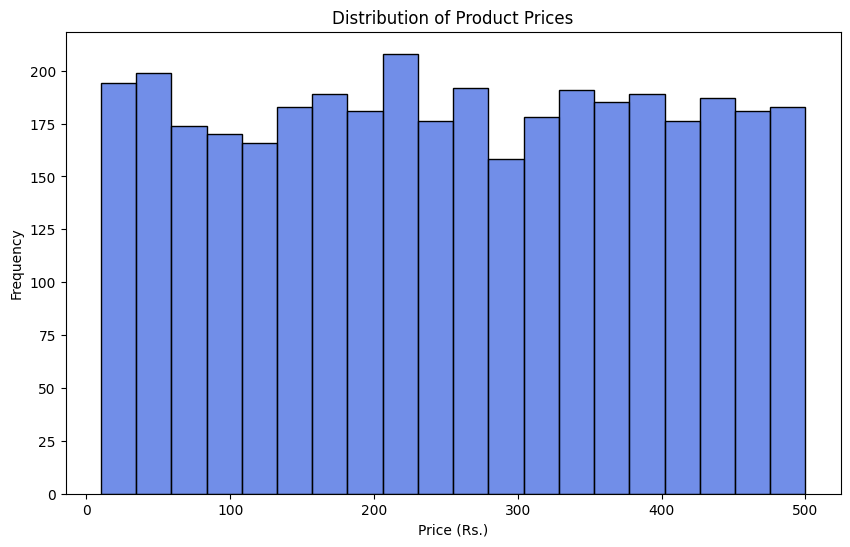

In [20]:
plt.figure(figsize=(10,6))                   # 8 is width and 5 is height
sns.histplot(                               # Ploting histogram
    data=df_estore,                         # Data 
    x="Price (Rs.)",                        # Column select
    bins=20,                                # Price range divide in 20 groups
  # kde=True                                # With Kernel Density Estimation
    color = "royalblue",
    edgecolor ="black"
)
plt.title("Distribution of Product Prices") # Giving a title
plt.xlabel("Price (Rs.)")                   # horizontal axis represents the product price.
plt.ylabel("Frequency")                     # vertical axis shows how many products fall into each price range.
plt.show()

## Price Outliers using Boxplot

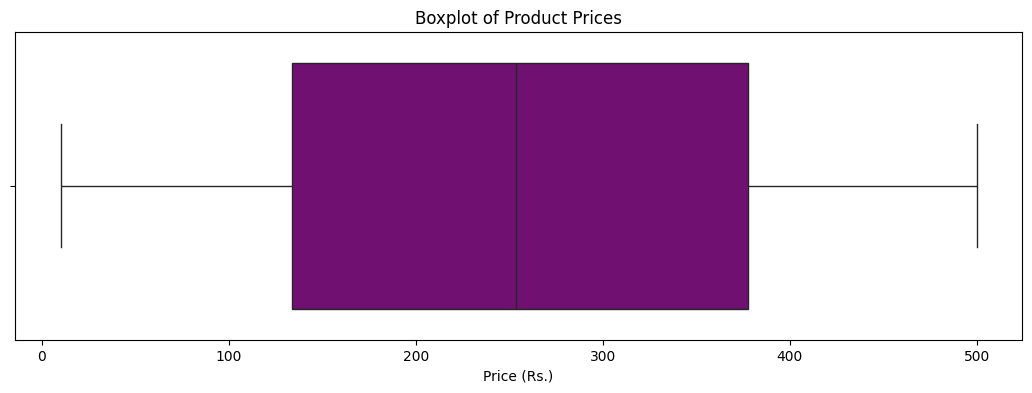

In [21]:
plt.figure(figsize=(13,4))                 # Creates a figure
sns.boxplot(                               # Creating a Box Plot
    x=df_estore["Price (Rs.)"],            # Creating a Column
    color = "purple",                       # Color selection
)
plt.title("Boxplot of Product Prices")     # Adding Title to a graph
plt.xlabel("Price (Rs.)")                  # labeling the x-axis
plt.show()                                 # Showing the graph

In [22]:
df_estore["Price (Rs.)"].max()


499.96

In [23]:
df_estore["Price (Rs.)"].describe()

count    3660.000000
mean      254.800675
std       141.682621
min        10.090000
25%       134.012500
50%       253.845000
75%       377.595000
max       499.960000
Name: Price (Rs.), dtype: float64

##  Histogram of Discount %

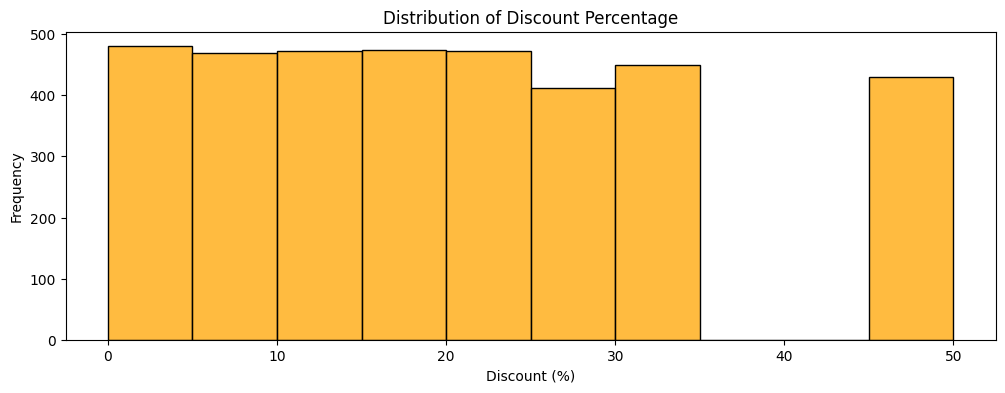

In [24]:
plt.figure(figsize=(12,4))
sns.histplot(
    x=df_estore["Discount (%)"],
    bins=10,
    color="orange",
    edgecolor="black"
)
plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.show()

## Boxplot of Discount (%)

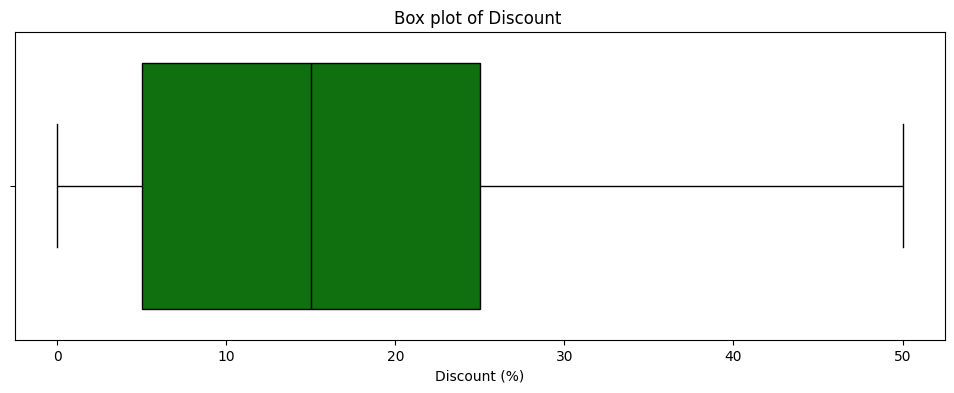

In [25]:
plt.figure(figsize=(12,4))
sns.boxplot(
    x=df_estore["Discount (%)"],
    color="green",
    linecolor="black"
)
plt.title("Box plot of Discount ")
plt.xlabel("Discount (%)")
plt.show()

## Countplot of Product category

In [26]:
df_estore["Category"].unique()

array(['Sports', 'Clothing', 'Toys', 'Beauty', 'Books', 'Home & Kitchen',
       'Electronics'], dtype=object)

In [27]:
df_estore["Category"].value_counts()

Category
Home & Kitchen    549
Books             534
Clothing          531
Toys              523
Sports            520
Beauty            505
Electronics       498
Name: count, dtype: int64

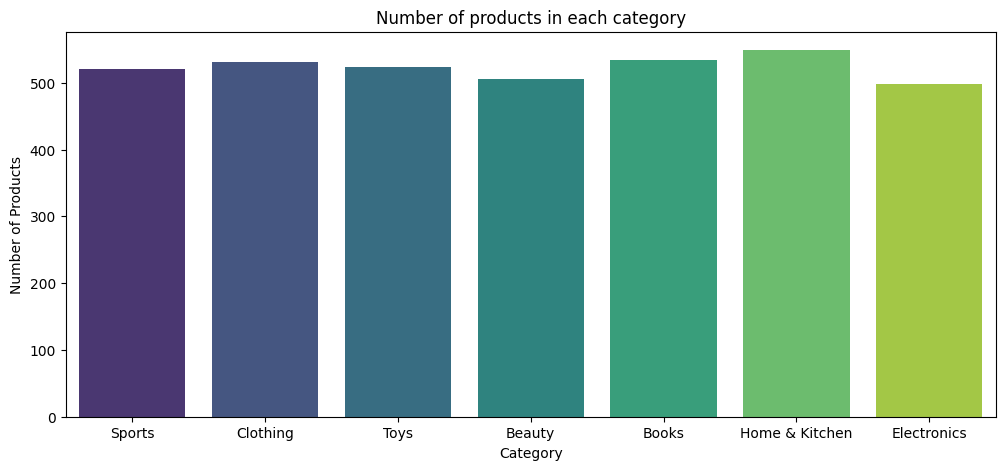

In [28]:
plt.figure(figsize=(12,5))
sns.countplot(
    x=df_estore["Category"],
    palette="viridis"
)
plt.title("Number of products in each category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=360)
plt.show()



## Purchase Trend by Month

In [29]:
df_estore["Month"] = df_estore["Purchase_Date"].dt.month_name()

In [30]:
df_estore["Month"].value_counts()

Month
April        362
October      362
March        355
July         346
August       344
September    342
January      340
May          333
June         323
February     308
November     245
Name: count, dtype: int64

In [31]:
#arranging months
month_order=["January","February","March","April","May","June","July","August","September","October","November","December"]

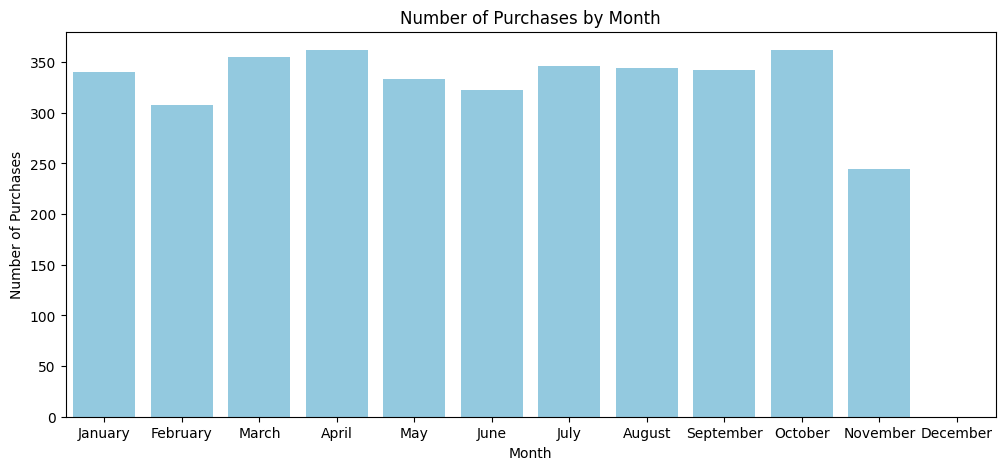

In [32]:
plt.figure(figsize=(12,5))

sns.countplot(
    x=df_estore["Month"],
    order=month_order,
    color="skyblue"
)

plt.title("Number of Purchases by Month")
plt.xlabel("Month")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=360)

plt.show()

# Bivariate Analysis

In [33]:
df_estore[["Price (Rs.)","Discount (%)"]].dtypes

Price (Rs.)     float64
Discount (%)      int64
dtype: object

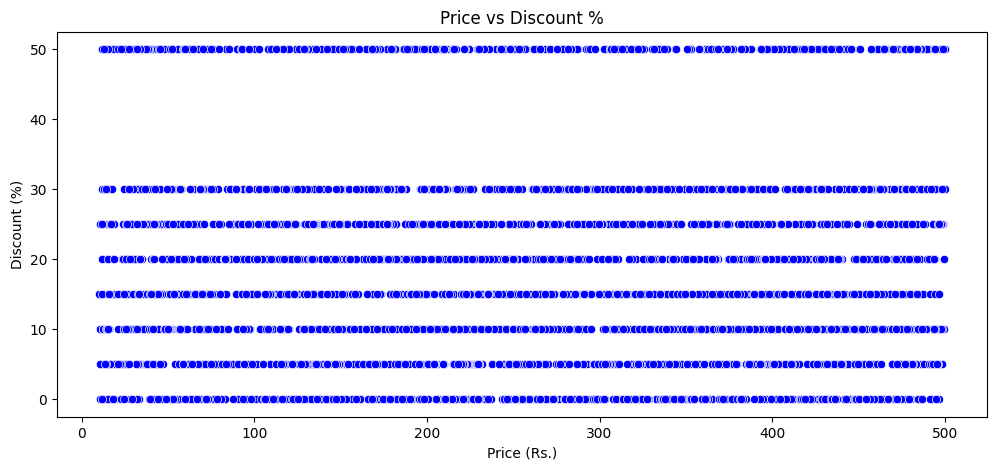

In [34]:
plt.figure(figsize=(12,5))

sns.scatterplot(
  x=df_estore["Price (Rs.)"],
  y=df_estore["Discount (%)"],
  color="blue"
)

plt.title("Price vs Discount %")
plt.xlabel("Price (Rs.)")
plt.ylabel("Discount (%)")

plt.show()

## Correlation Analysis (HeatMap)

In [35]:
numeric_df = df_estore.select_dtypes(include="number")
numeric_df.head()

,Price (Rs.),Discount (%),Final_Price(Rs.)
0,36.53,15,31.05
1,232.79,20,186.23
2,317.02,25,237.76
3,173.19,25,129.89
4,244.80,20,195.84


In [36]:
numeric_df.corr()

,Price (Rs.),Discount (%),Final_Price(Rs.)
Price (Rs.),1.000000,-0.003473,0.935691
Discount (%),-0.003473,1.000000,-0.311515
Final_Price(Rs.),0.935691,-0.311515,1.000000


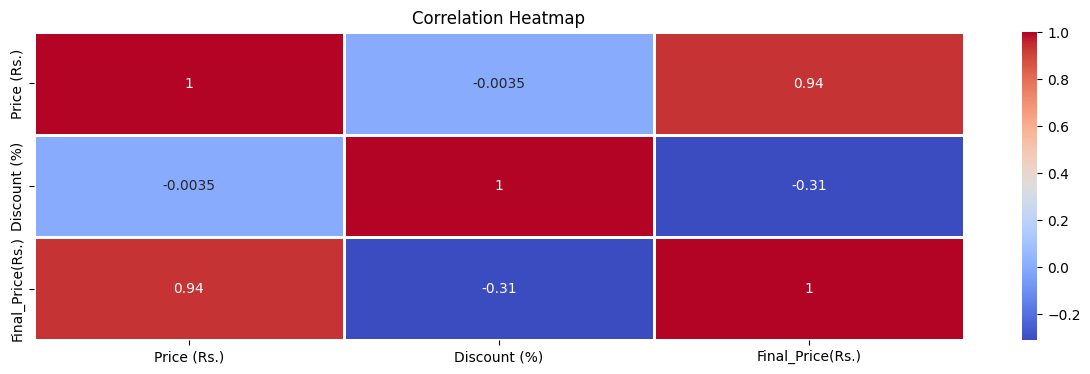

In [37]:
plt.figure(figsize=(15,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()

## Category vs Price (Box plot)

In [38]:
df_estore["Category"].unique()

array(['Sports', 'Clothing', 'Toys', 'Beauty', 'Books', 'Home & Kitchen',
       'Electronics'], dtype=object)

In [39]:
df_estore["Category"].value_counts()

Category
Home & Kitchen    549
Books             534
Clothing          531
Toys              523
Sports            520
Beauty            505
Electronics       498
Name: count, dtype: int64

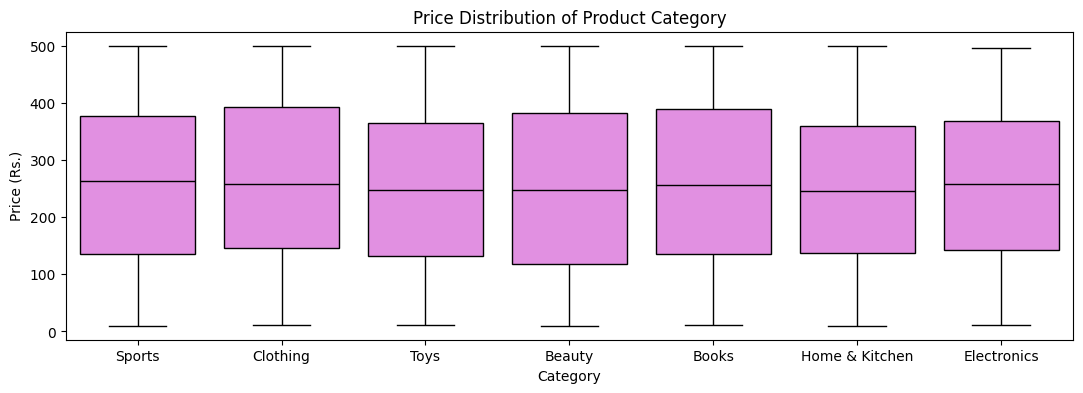

In [40]:
plt.figure(figsize=(13,4))

sns.boxplot(
    x=df_estore["Category"],
    y=df_estore["Price (Rs.)"],
    color="violet",
    linecolor="black"
)

plt.title("Price Distribution of Product Category")
plt.xlabel("Category")
plt.ylabel("Price (Rs.)")

plt.xticks(rotation=360)

plt.show()

## Average Price of Each Category (Bar Plot)

In [41]:
df_estore.groupby("Category")["Price (Rs.)"].mean()

Category
Beauty            252.738693
Books             259.123052
Clothing          263.115913
Electronics       251.646867
Home & Kitchen    249.255938
Sports            258.619212
Toys              248.962772
Name: Price (Rs.), dtype: float64

In [42]:
df_estore.groupby("Category")

In [43]:
avg_price=df_estore.groupby("Category")["Price (Rs.)"].mean()

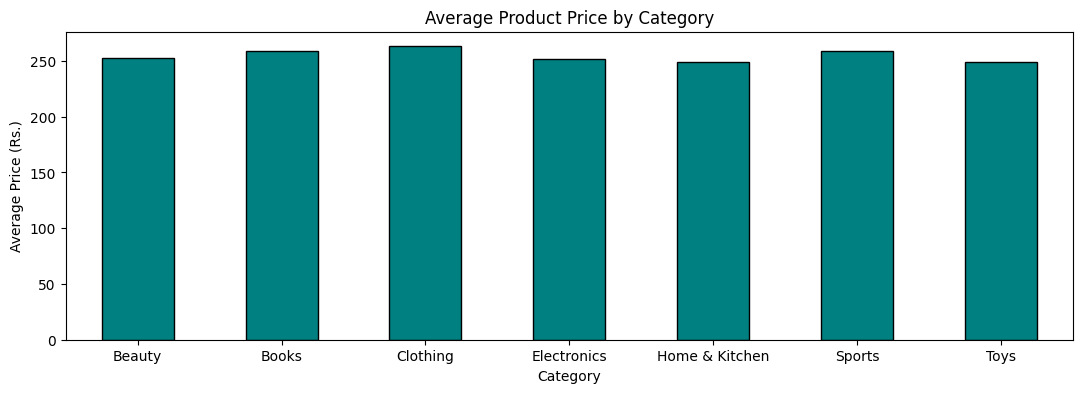

In [44]:
plt.figure(figsize=(13,4))

avg_price.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Average Product Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (Rs.)")

plt.xticks(rotation=360)

plt.show()

## Average Discount by Category by Bar Chart

In [45]:
df_estore.groupby("Category")["Discount (%)"].mean()

Category
Beauty            18.475248
Books             19.035581
Clothing          17.919021
Electronics       19.267068
Home & Kitchen    19.608379
Sports            19.326923
Toys              18.126195
Name: Discount (%), dtype: float64

In [46]:
avg_discount=df_estore.groupby("Category")["Discount (%)"].mean()

In [47]:
df_estore.groupby("Category")

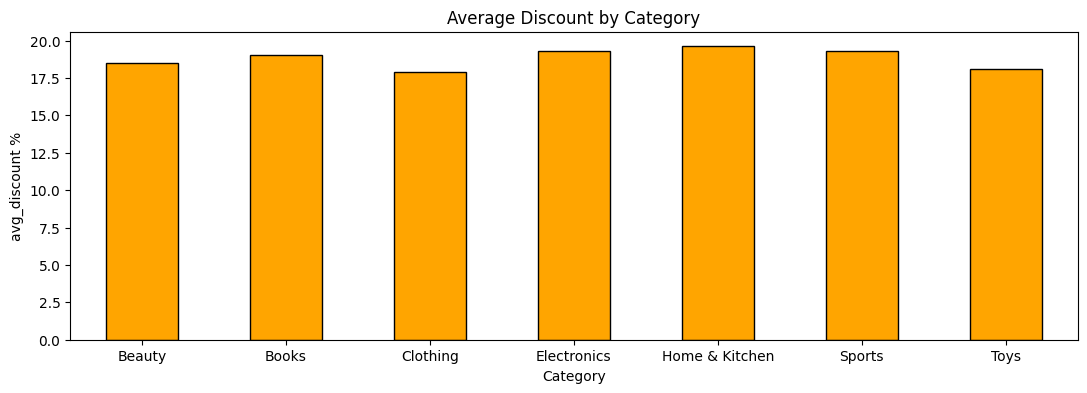

In [48]:
plt.figure(figsize=(13,4))

avg_discount.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("avg_discount %")

plt.xticks(rotation=360)

plt.show()

# Univariate Analysis

## The relationship among three numerical variables simultaneously: Price (Rs.), Discount (%), Final_Price (Rs.) Using pairplot

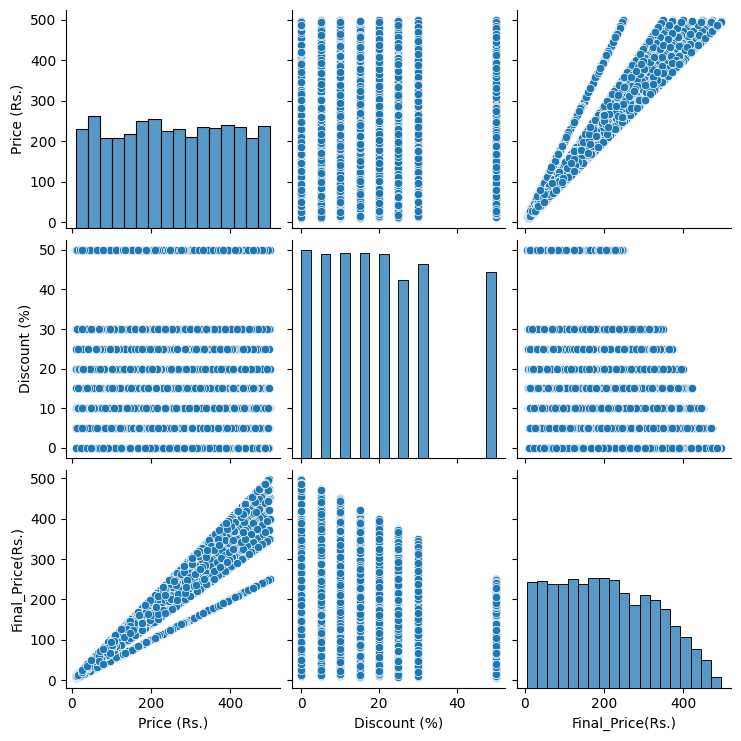

In [49]:
sns.pairplot(
    df_estore[
        ["Price (Rs.)","Discount (%)", "Final_Price(Rs.)"]
    ], 
    diag_kind="hist"
)

plt.show()

## Compare Price Distribution by Category Using Hue (Grouped Box Plot)

In [50]:
def discount_level(discount):
    if discount <=10:
        return "Low"
    elif discount <= 25:
        return "Medium"
    else:
        return "High"

In [51]:
df_estore["Discount_Level"] = df_estore["Discount (%)"].apply(discount_level)

In [52]:
df_estore[["Discount (%)","Discount_Level"]].head(11)

,Discount (%),Discount_Level
0,15,Medium
1,20,Medium
2,25,Medium
3,25,Medium
4,20,Medium
5,50,High
6,5,Low
7,20,Medium
8,5,Low
9,50,High


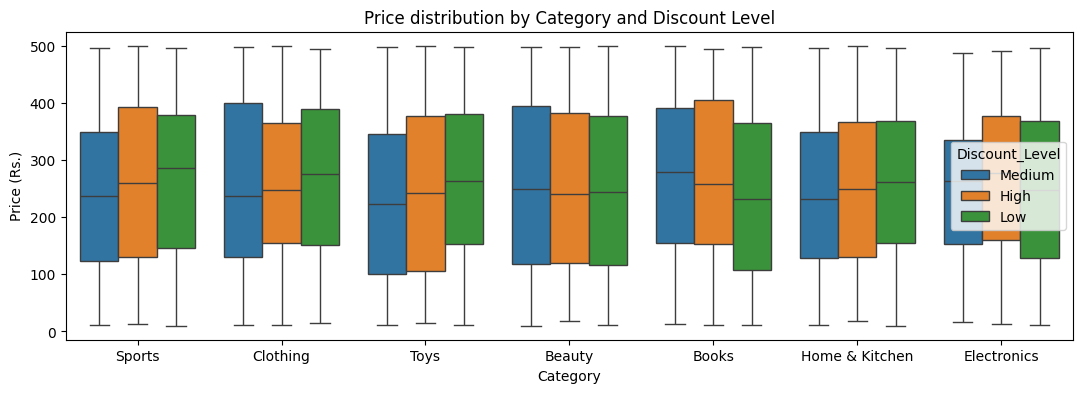

In [53]:
plt.figure(figsize=(13,4))

sns.boxplot(
    data=df_estore,
    x="Category",
    y="Price (Rs.)",
    hue="Discount_Level"
)

plt.title("Price distribution by Category and Discount Level")
plt.xlabel("Category")
plt.ylabel("Price (Rs.)")

plt.xticks(rotation=360)

plt.show()

## Analyze Four variables at a same time with using bubble chart

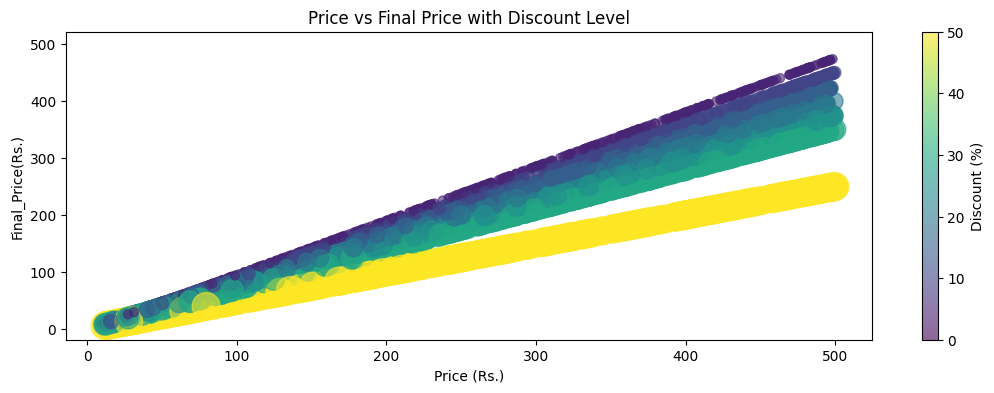

In [54]:
plt.figure(figsize=(13,4))

plt.scatter(
    x=df_estore["Price (Rs.)"],
    y=df_estore["Final_Price(Rs.)"],
    s=df_estore["Discount (%)"]*8,
    c=df_estore["Discount (%)"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Discount (%)")

plt.title("Price vs Final Price with Discount Level")
plt.xlabel("Price (Rs.)")
plt.ylabel("Final_Price(Rs.)")

plt.show()

## Price Distribution by Category using Violin Plot

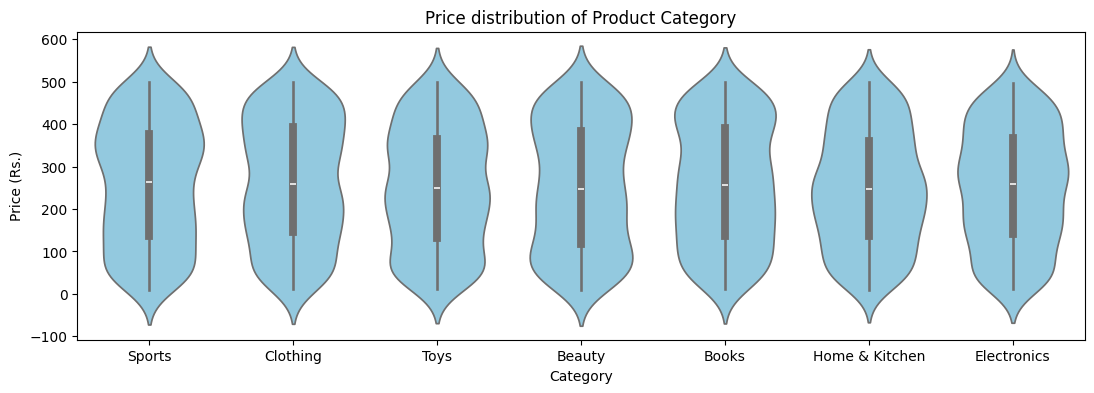

In [55]:
plt.figure(figsize=(13,4))

sns.violinplot(
    data=df_estore,
    x="Category",
    y="Price (Rs.)",
    color="skyblue"
)

plt.title("Price distribution of Product Category")
plt.xlabel("Category")
plt.ylabel("Price (Rs.)")

plt.xticks(rotation=360)

plt.show()

## Bubble Chart (4 Variables in One Graph)

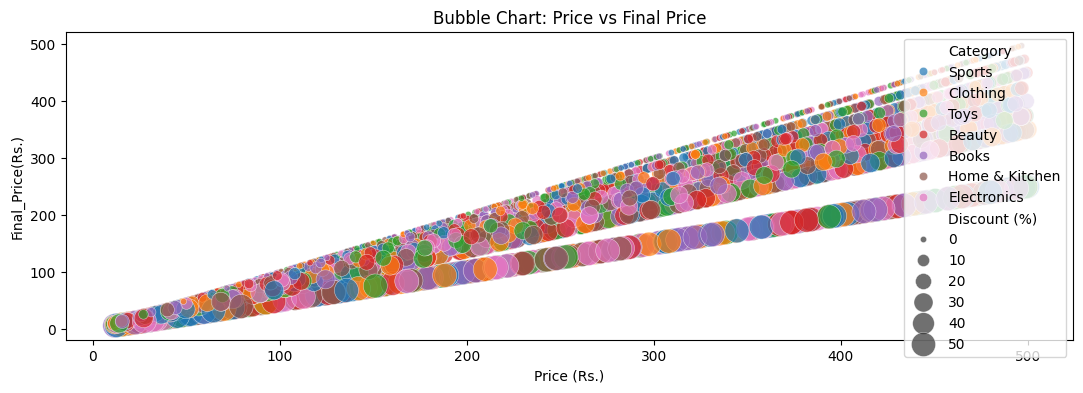

In [56]:
plt.figure(figsize=(13,4))

sns.scatterplot(
    data=df_estore,
    x="Price (Rs.)",
    y="Final_Price(Rs.)",
    size="Discount (%)",
    hue="Category",
    sizes=(20,300),
    alpha=0.7
)

plt.title("Bubble Chart: Price vs Final Price")
plt.xlabel("Price (Rs.)")
plt.ylabel("Final_Price(Rs.)")

plt.show()

## Pivot Table Analysis

In [57]:
pivot_price=pd.pivot_table(
    df_estore,
    values="Price (Rs.)",
    index="Category",
    aggfunc="mean"
)

pivot_price


,Price (Rs.)
Category,
Beauty,252.738693
Books,259.123052
Clothing,263.115913
Electronics,251.646867
Home & Kitchen,249.255938
Sports,258.619212
Toys,248.962772


In [58]:
pivot_summary=pd.pivot_table(
    df_estore,
    values=["Price (Rs.)","Discount (%)","Final_Price(Rs.)"],
    index="Category",
    aggfunc=["mean","min","max"]
)

pivot_summary

mean                                       min  \
               Discount (%) Final_Price(Rs.) Price (Rs.) Discount (%)   
Category                                                                
Beauty            18.475248       206.366535  252.738693            0   
Books             19.035581       208.144850  259.123052            0   
Clothing          17.919021       217.165424  263.115913            0   
Electronics       19.267068       201.731386  251.646867            0   
Home & Kitchen    19.608379       200.961894  249.255938            0   
Sports            19.326923       208.689981  258.619212            0   
Toys              18.126195       205.142811  248.962772            0   

                                                     max                   \
               Final_Price(Rs.) Price (Rs.) Discount (%) Final_Price(Rs.)   
Category                                                                    
Beauty                     8.58       10.09           50           486.79   
Books                      5.89       11.78           50           487.06   
Clothing                   7.33       11.59           50           495.02   
Electronics                8.97       11.16           50           472.29   
Home & Kitchen             8.12       10.37           50           496.82   
Sports                     6.35       10.33           50           493.04   
Toys                       7.49       11.54           50           477.48   

                            
               Price (Rs.)  
Category                    
Beauty              499.65  
Books               499.36  
Clothing            499.91  
Electronics         496.76  
Home & Kitchen      499.03  
Sports              499.96  
Toys                499.00

## Crosstab Analysis

In [59]:
cross_tab = pd.crosstab(
    df_estore["Category"],
    df_estore["Discount_Level"]
)

cross_tab

Discount_Level,High,Low,Medium
Category,,,
Beauty,125,197,183
Books,127,205,202
Clothing,107,208,216
Electronics,125,194,179
Home & Kitchen,144,197,208
Sports,136,199,185
Toys,115,223,185


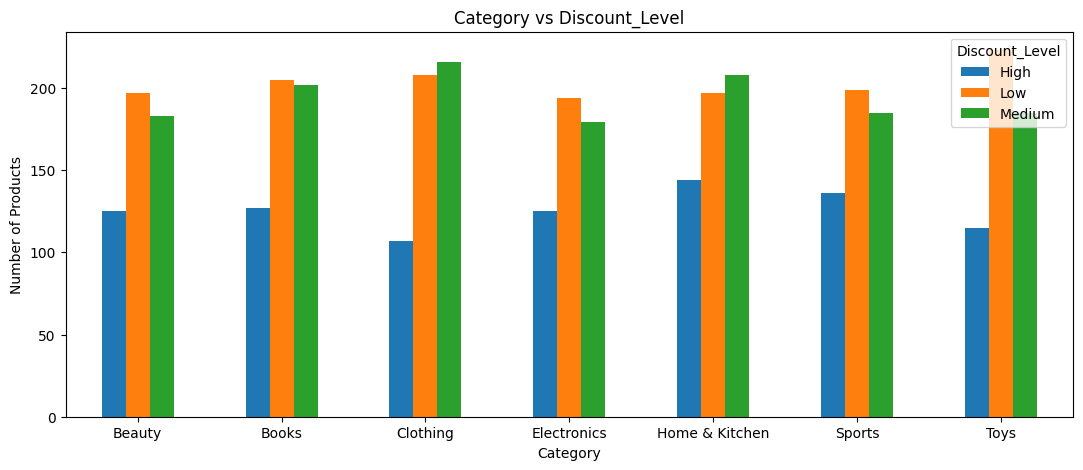

In [60]:
cross_tab.plot(
    kind="bar",
    figsize=(13,5)
)

plt.title("Category vs Discount_Level")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.xticks(rotation = 0)

plt.show()